In [28]:
#Library imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Datasets imports
space_missions = pd.read_csv("re_worked/final/space_mission_dataset.csv")
movies = pd.read_csv("re_worked/movies_dataset.csv")

In [81]:
#Additional cleaning that I missed

#Converting both sets' date columns to datetime
space_missions['date'] = pd.to_datetime(space_missions['date'], format = "%d/%m/%Y")
movies['release_date'] = pd.to_datetime(movies['release_date'])

Notes from the below three visuals (space missions data)

Firstly, my reliable data ends in 2023. My dataset is incomplete for 2024, so maybe it would be best to leave that year out.

Secondly, from around 1964 until 1990 the number of missions remained above 100 year. The 1960's saw the biggest leap in mission launches (at the end of the space race, when Kenedy wanted to put a man on the moon, before the end of the decade). Something happened in the 90's or just before the decade, which made the space efforts begin to drop slowly, but steadily. 2000 - 2005 the number of space launches were almost at the same level as in 1961. By 2009 the number of mission launches had begun to climb slowly. 

A huge difference can be seen when comparing 1960-1990 with 1991-2017. Something happened around 2020 which made mission launches to skyrocket in number.

I wanted to see which country had the most launch missions and was suprised to find Kazakhstan among the top 3. After some research, I found out that the Baikonur Cosmodrome is located is Kazahstan, which was and still is a central hub for Russia's space missions. Because of that, I decided to group the two countries toghether in future charts. I grouped the launches by country and decade (filtering to have only the top 3 countries) and saw that after 'winning' the space race, the US significantly reduced it's launch missions, while Russia doubled theirs. It seems that from the 70s (around) onwards, China began it's own space program, which developed over the decades, reaching the US and Russia's output by the 2010s. That's around when the US began mounting more missions again.

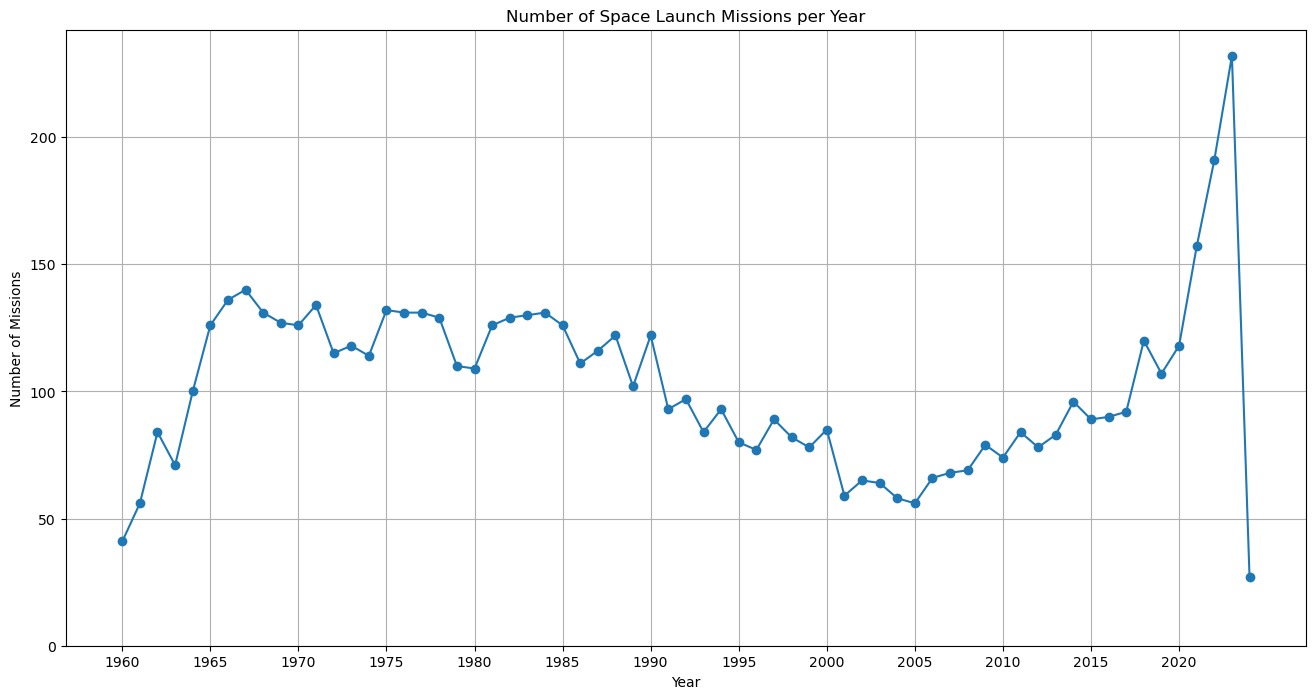

In [52]:
#Creating a number of launches per year visual

#Creating an extra column with just the year, so I can group by it
space_missions['year'] = space_missions['date'].dt.year

#Counting the missions per year and grouping them
missions_per_year = space_missions.groupby('year').size()

#Visualizing the number of space missions per year
plt.figure(figsize = (16,8))
plt.plot(missions_per_year.index, missions_per_year.values, marker='o')

#Increasing the number of x ticks
plt.xticks(range(missions_per_year.index.min(),
                 missions_per_year.index.max() + 1,
                 5))

#Increasing the number of y ticks
plt.yticks(range(0,
                 missions_per_year.values.max() + 1,
                 50))

#Populating the chart
plt.title("Number of Space Launch Missions per Year")
plt.xlabel("Year")
plt.ylabel("Number of Missions")
plt.grid(True)

plt.show()

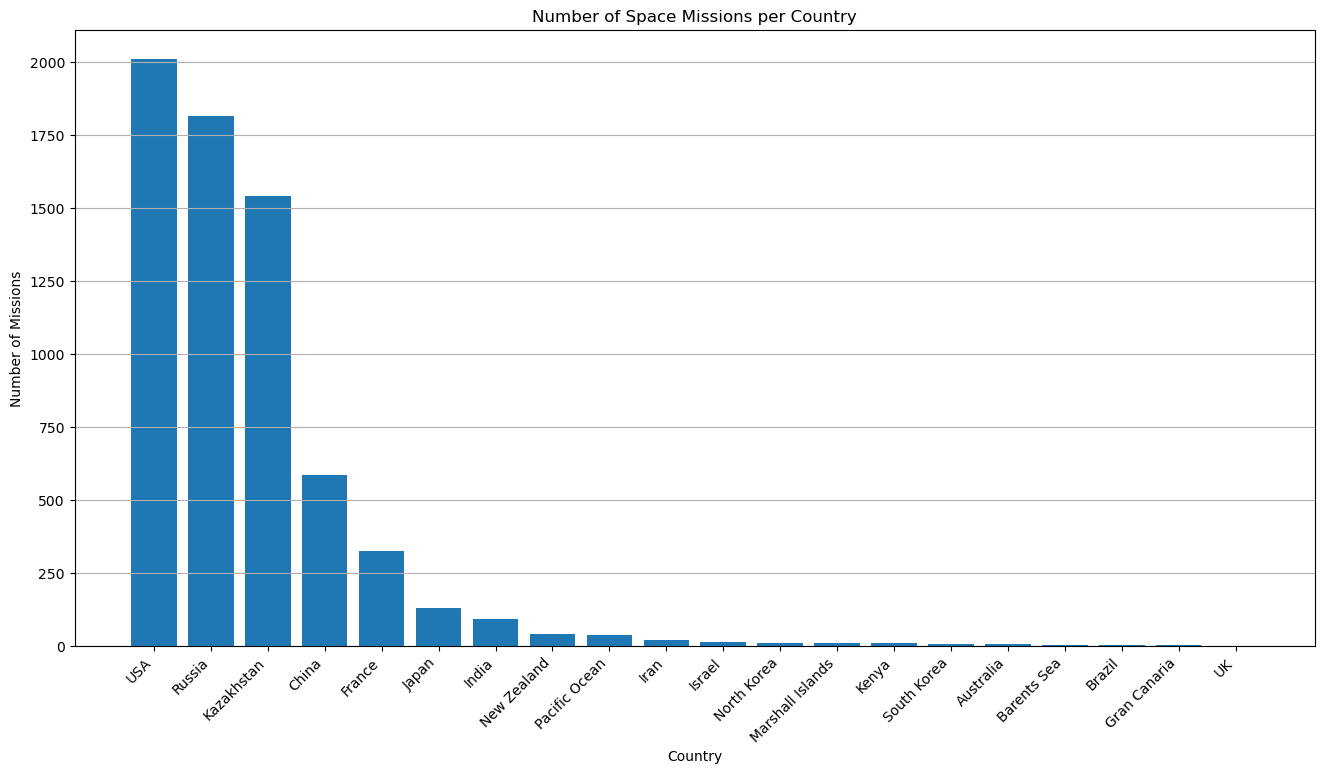

In [64]:
#Ploting the number of launch missions by country - here I notices Kazakhstan

#Counts missions per country
missions_per_country = space_missions['launch_location'].value_counts()

#Visualizes the result 
plt.figure(figsize=(16,8))
plt.bar(missions_per_country.index, missions_per_country.values)

#Populating the chart
plt.title("Number of Launch Missions per Country")
plt.xlabel("Country")
plt.ylabel("Number of Missions")

#Rotates lables and prevents overlap
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

<Figure size 1800x900 with 0 Axes>

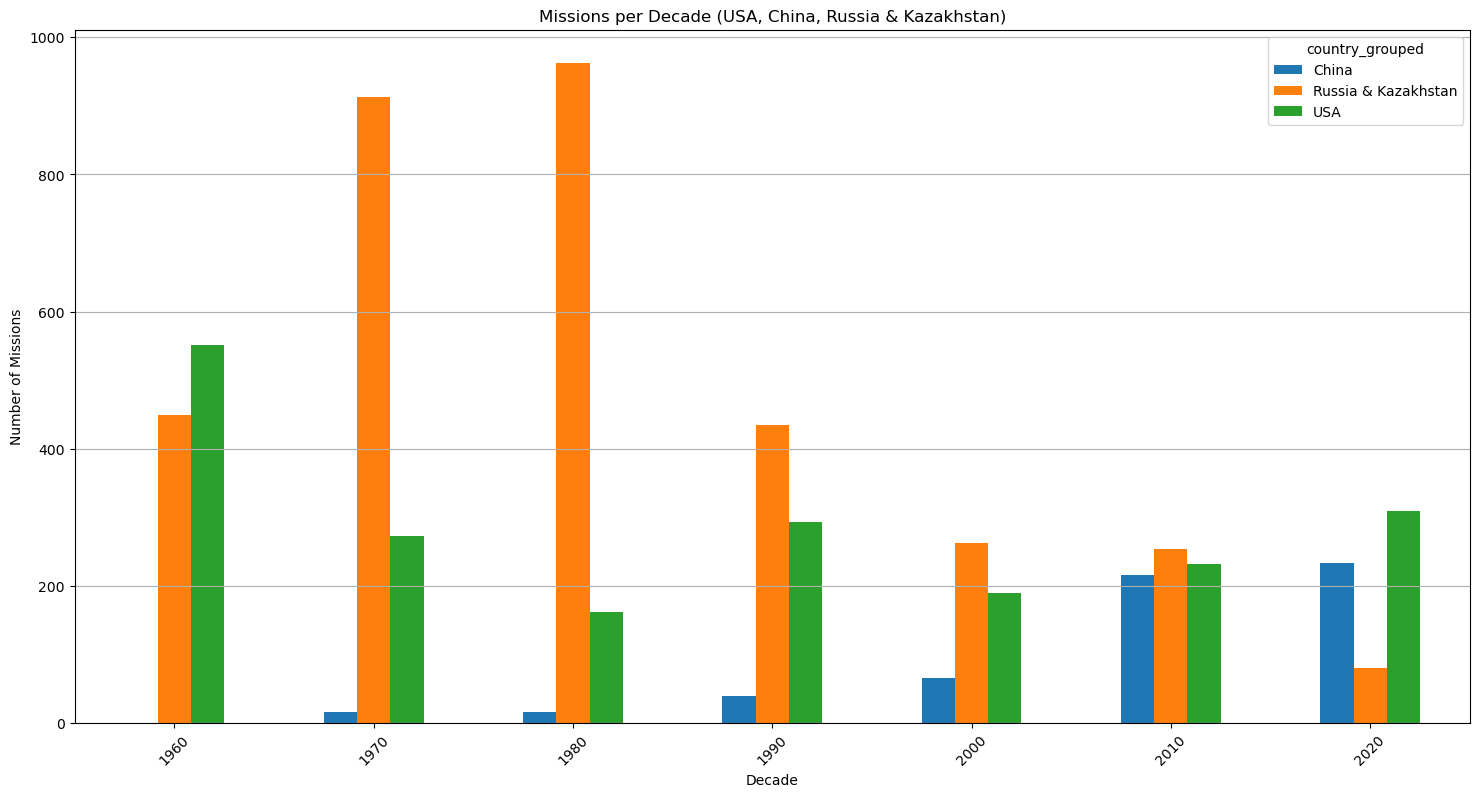

In [77]:
#Group the launch mission by country and decade; Russia and Kazakhstan are grouped
#Creates a decade column
space_missions["decade"] = (space_missions["date"].dt.year // 10) * 10

#Merging Russia and Kazakhstan
space_missions.loc[space_missions["launch_location"] == "Russia", "launch_location"] = "Russia & Kazakhstan"
space_missions.loc[space_missions["launch_location"] == "Kazakhstan", "launch_location"] = "Russia & Kazakhstan"

#Filtering the set to only include the top 3 countries with the most launches
top_3 = ["USA", "China", "Russia & Kazakhstan"]
missions = space_missions[space_missions["country_grouped"].isin(top_3)]

#Grouping by decade and country
counts_decade_country = missions.groupby(["decade", "country_grouped"]).size()

#Creating a table, using the grouped data
counts_decade_country = counts.unstack(fill_value=0)

#Plotting the data
plt.figure(figsize=(18,9))
counts.plot(kind="bar", stacked=False, figsize=(18,9))

#Populating the chart
plt.title("Missions per Decade (USA, China, Russia & Kazakhstan)")
plt.xlabel("Decade")
plt.ylabel("Number of Missions")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

Notes on below visuals (movies data)

Firstly, I need to limit the movies to 2023, so as to keep with the launch missions dataset. Also, there isn't enough information for 2025.

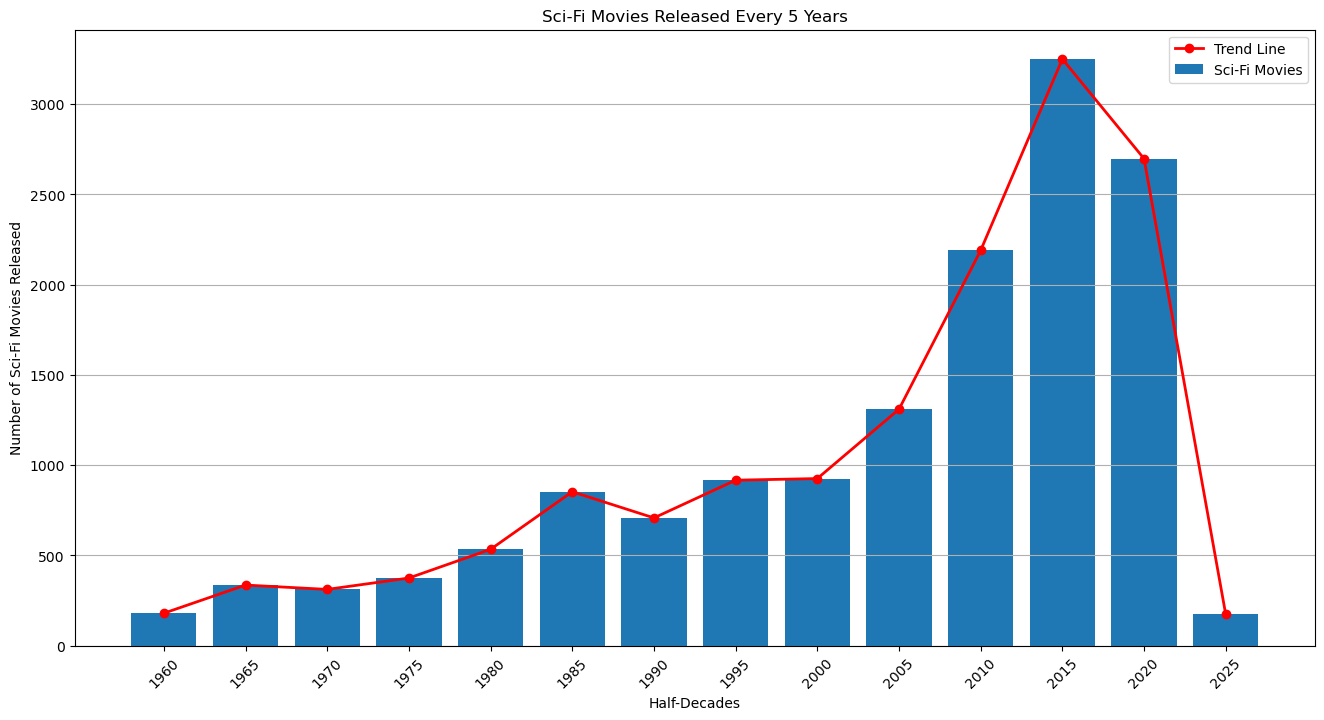

In [100]:
#Create a five year period column to group by
movies["five_year"] = (movies["release_date"].dt.year // 5) * 5

#Search for SciFi movies only and count them
sci_fi = movies[movies["genres"].str.contains("Science Fiction", na=False)]
sci_fi_count = sci_fi.groupby("five_year").size()

#Plotting the visual
plt.figure(figsize=(16,8))

#Creating the bar chart and the line chart
plt.bar(sci_fi_counts.index, sci_fi_counts.values, width=4, label="Sci-Fi Movies")
plt.plot(sci_fi_count.index, sci_fi_count.values, color="red", marker="o", linewidth=2, label="Trend Line")

#Populating the visual
plt.title("Sci‑Fi Movies Released Every 5 Years")
plt.xlabel("Half-Decades")
plt.ylabel("Number of Sci‑Fi Movies Released")
plt.xticks(sci_fi_counts.index, rotation=45)
plt.grid(axis="y")
plt.legend()

plt.show()

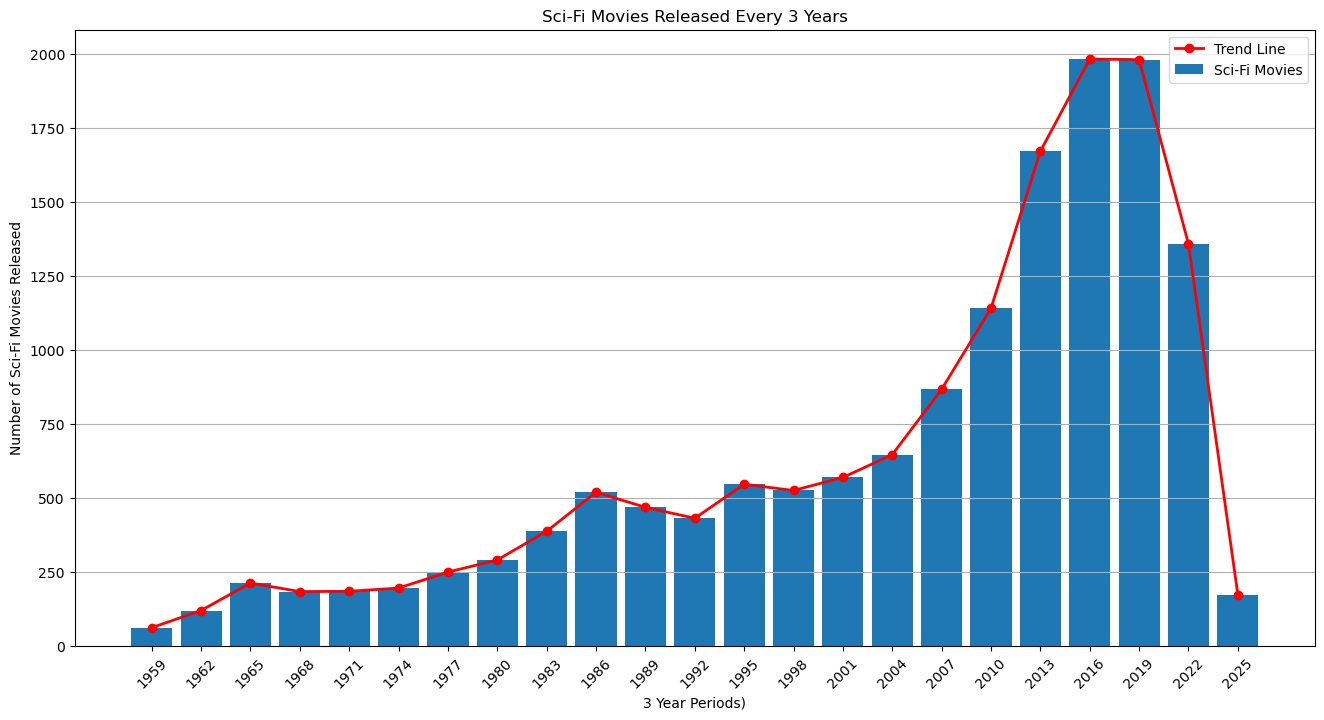

In [101]:
#Create a three year period column to group by
movies["three_year"] = (movies["release_date"].dt.year // 3) * 3

#Search for SciFi movies only and count them
sci_fi = movies[movies["genres"].str.contains("Science Fiction", na=False)]
sci_fi_counts = sci_fi.groupby("three_year").size()

#Plotting the visual
plt.figure(figsize=(16,8))

#reating the bar chart and line charts
plt.bar(sci_fi_counts.index, sci_fi_counts.values, width=2.5, label="Sci-Fi Movies")
plt.plot(sci_fi_counts.index, sci_fi_counts.values, color="red", marker="o", linewidth=2, label="Trend Line")

#Populating the visual
plt.title("Sci‑Fi Movies Released Every 3 Years")
plt.xlabel("3 Year Periods)")
plt.ylabel("Number of Sci‑Fi Movies Released")
plt.xticks(sci_fi_counts.index, rotation=45)
plt.grid(axis="y")
plt.legend()

plt.show()